# SmartCart - E-commerce Customer Segmentation System

In [1]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("smartcart_customers.csv") 

In [3]:
data.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data preprocessing


## 1. fill missing values


In [5]:

data["Income"] = data["Income"].fillna(data["Income"].median())

## Feature Engineering

In [6]:
# Age
data["Age"] = 2026- data["Year_Birth"]

In [7]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [8]:
# Customer Joining Date

data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst= True)

reference_date = data["Dt_Customer"].max()
data["Customer_Tenure_Days"] = (reference_date-data["Dt_Customer"]).dt.days

In [9]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [10]:
# Spending and Children

data["Total_spending"] = data["MntWines"]+data["MntFruits"]+data["MntMeatProducts"]+data["MntFishProducts"]+data["MntSweetProducts"]+data["MntGoldProds"]
data["Total_children"] = data["Kidhome"]+data["Teenhome"]

In [11]:
# Education

data["Education"].value_counts()

data["Education"] = data["Education"].replace({
    "Basic": "Undergraduate", 
    "2n Cycle": "Undergraduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate",
    "Graduation": "Graduate"
})

In [12]:
# Marital Status

data["Marital_Status"].value_counts()


data["Living_With"] = data["Marital_Status"].replace({
    "Married": "Partner", 
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

In [13]:
# Drop Columns

cols = ["ID", "Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

data_cleaned = data.drop(columns = cols)

In [14]:
data_cleaned.shape

(2240, 15)

In [15]:
data_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers

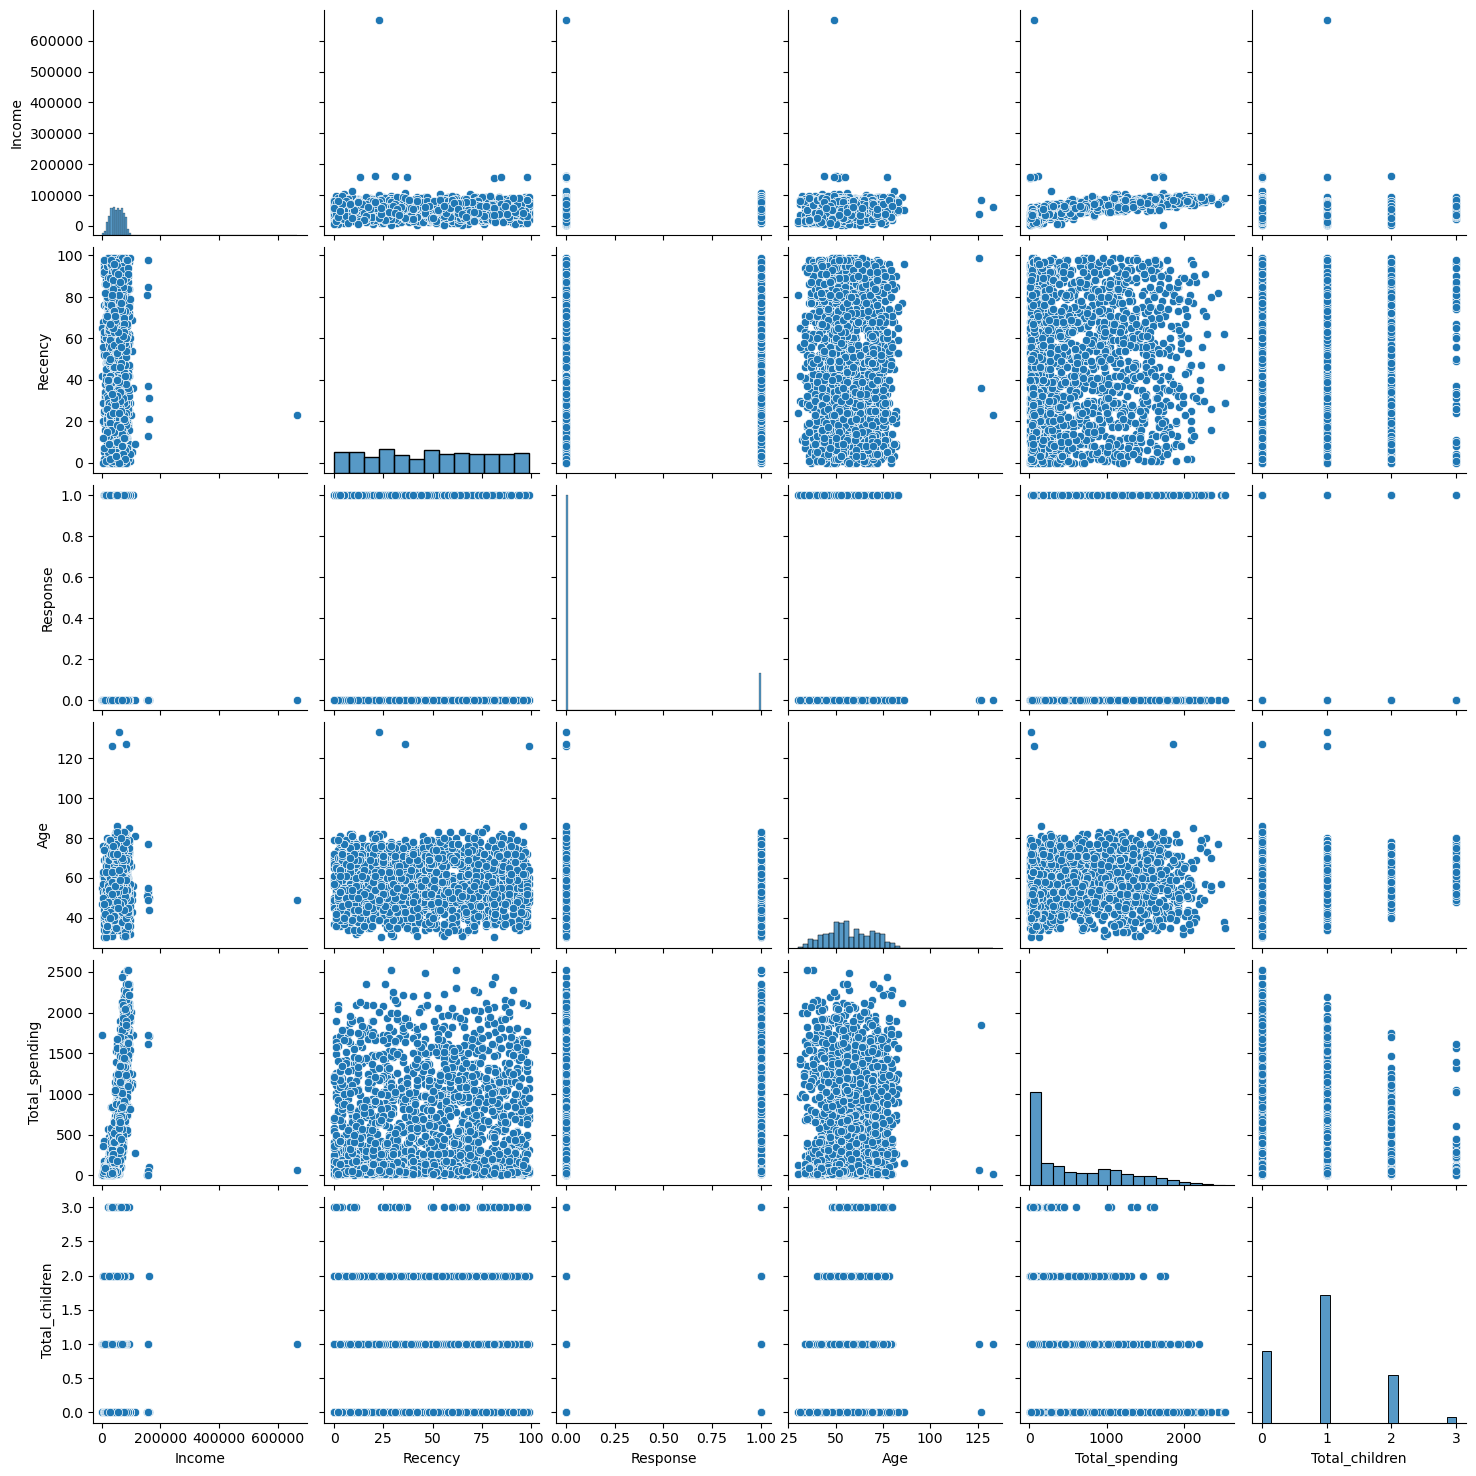

In [16]:
cols = ["Income","Recency","Response","Age", "Total_spending","Total_children"]

# Relative plots of some features - pair plots

sns.pairplot(data_cleaned[cols])

In [17]:
# Remove Outliers

print("data size with outliers: ", len(data_cleaned))

data_cleaned = data_cleaned[(data_cleaned["Age"] < 90)]
data_cleaned = data_cleaned[(data_cleaned["Income"] < 600_000)]

print("data size without outliers: ", len(data_cleaned))


data size with outliers:  2240
data size without outliers:  2236


## Heatmap


In [18]:
corr = data_cleaned.corr(numeric_only = True)

<Axes: >

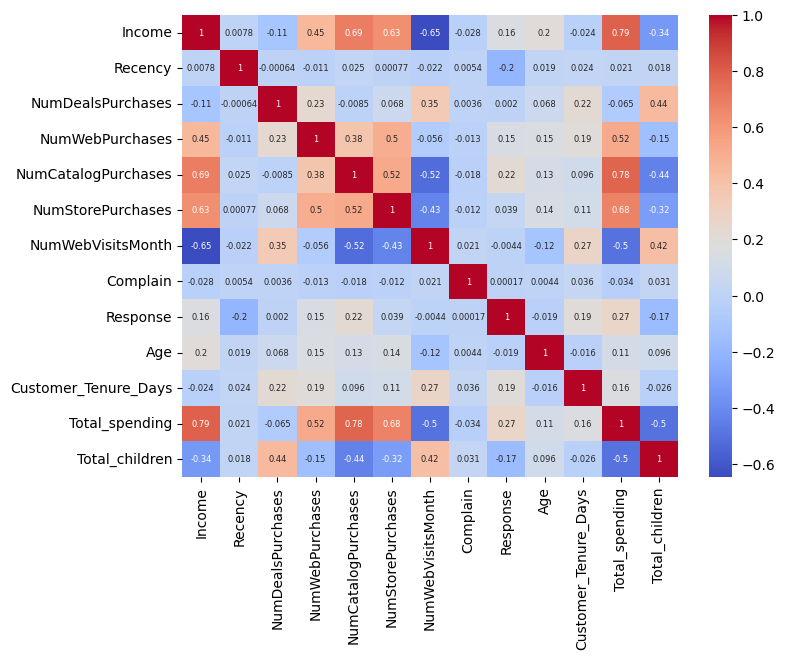

In [19]:
plt.figure(figsize = (8,6))

sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size": 6},
    cmap = "coolwarm"
)

## Encoding



In [20]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()  # we dont do drop first in clustering based code because meaningful data might get lost

cat_cols = ["Education" , "Living_With"]

enc_cols = ohe.fit_transform(data_cleaned[cat_cols])

In [21]:
enc_data = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols),index=data_cleaned.index)

In [22]:
data_encoded =pd.concat([data_cleaned.drop(columns = cat_cols), enc_data], axis = 1)

## Scaling

In [23]:
X = data_encoded

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualize



In [25]:
from sklearn.decomposition import PCA

# 2D
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)



In [26]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D projection')

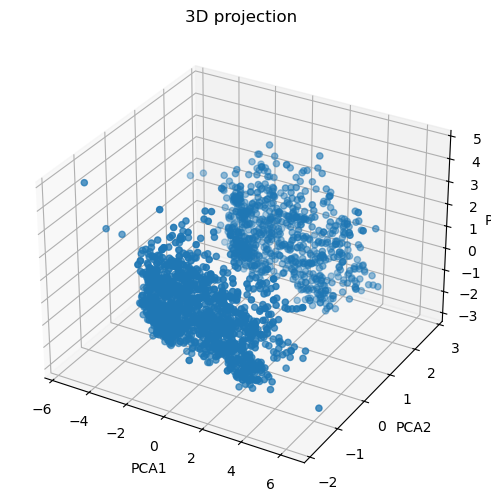

In [27]:
# plot
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection= "3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2]
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

In [28]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze the K value

## 1. Elbow Method

In [29]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

C:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [32]:
knee = KneeLocator(range(1,11), wcss, curve = "convex",direction="decreasing")
optimal_k = knee.elbow

In [34]:
print("best k = ",optimal_k)

best k =  4


Text(0, 0.5, 'WCSS')

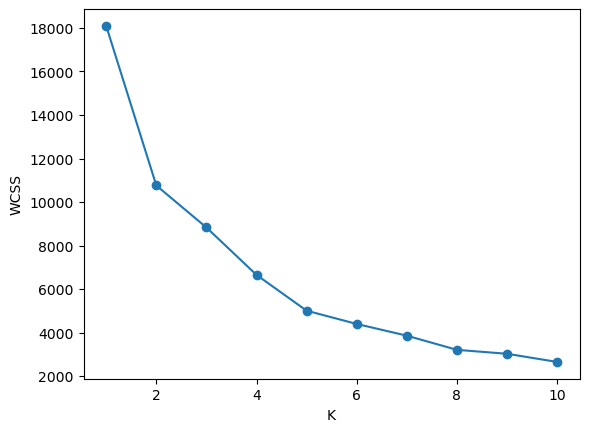

In [48]:
# plot

plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")



## Silhouette score

C:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Text(0, 0.5, 'Silhouette score')

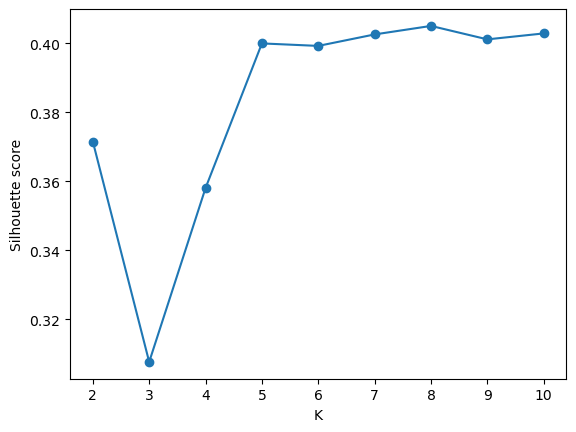

In [40]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

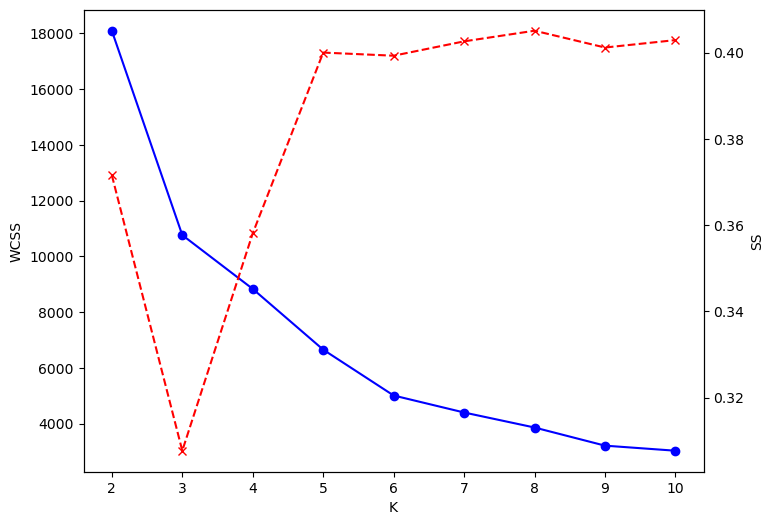

In [50]:
# Combined plot

k_range = range(2,11)

fig,ax1 = plt.subplots(figsize = (8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker = 'o',color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker = "x", color = "red", linestyle="--")
ax2.set_ylabel("SS")

# Clustering

In [51]:
# K Means

kmeans = KMeans(n_clusters = 4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

C:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


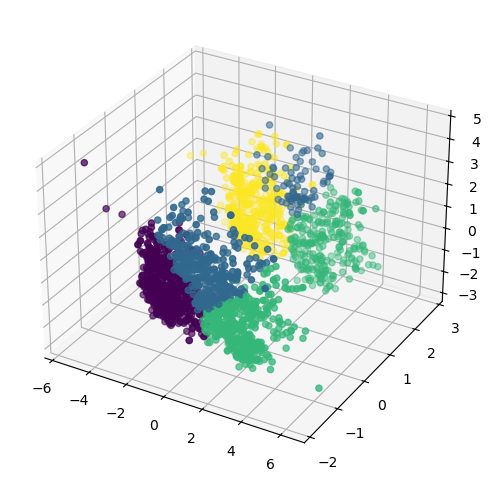

In [52]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection= "3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c = labels_kmeans
)

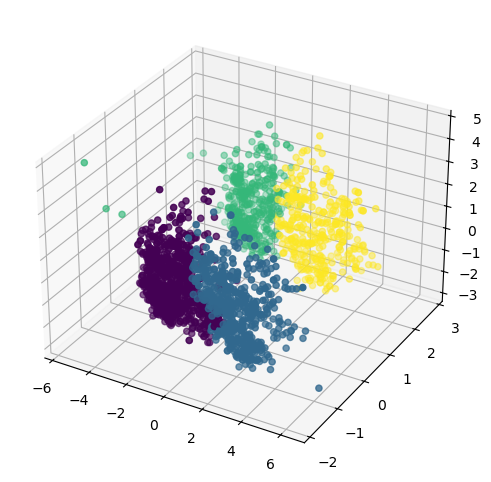

In [54]:
# Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage = "ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection= "3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c = labels_agg
)

# Characterization of Clusters

In [68]:

X["cluster"]= labels_agg


In [69]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

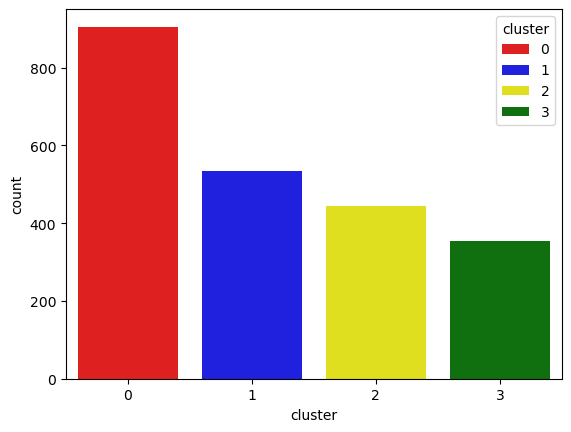

In [72]:
pal = ["red","blue","yellow","green"]

sns.countplot(x= X["cluster"], palette= pal, hue= X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

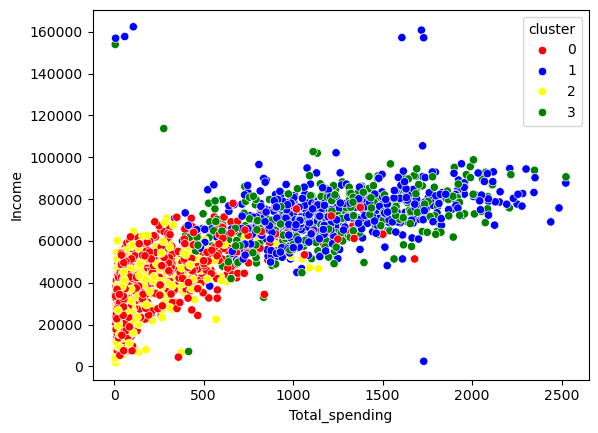

In [73]:
# Income and Spending Patterns

sns.scatterplot(x=X["Total_spending"], y= X["Income"], hue=X["cluster"], palette = pal)

In [74]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         